In [1]:
# Polynomial fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Advertising.csv").iloc[:,1:]
df.head()
df_small = df.iloc[[10,20,30,40,50],[0,-1]]
df_small

,TV,Sales
10,66.1,8.6
20,218.4,18.0
30,292.9,21.4
40,202.5,16.6
50,199.8,11.4


In [3]:
xInput = df_small.iloc[[0,1,3,4],0].values
yInput = df_small.iloc[[0,1,3,4],-1].values
xTest = df_small.iloc[2,0]
yTest = df_small.iloc[2,1]

In [4]:
# Polynomial fit
class polyFit:
    def __init__(self):
        self.n = 0
        self.x = 0
        self.y = 0

    def modelFit(self, xInput, n):
        for i in range(1, n+1):
            xSub = xInput.reshape(-1,1) ** i
            if (i == 1):
                x = np.hstack( [ xSub, np.ones((len(xInput),1)) ]) # x matrix for training data
            else:
                x = np.hstack([xSub, x]) # x matrix for training data
        return x

    def minFind(self, x, y):
        # Apply normal equation to find minimum for slopes and y-intercept parameters
        xtx = x.T @ x
        w = np.linalg.inv(xtx) @ x.T @ y
        return w

    def polyPlot(self, w, xInput, yInput, xTest, yTest):
        wReversed = w[::-1]
        xPlot = np.arange(0, max(xInput)+100, 0.1)
        for i in range(0, len(wReversed)):
            if (i == 0):
                yPlot = wReversed[i]
            if (i > 0):
                yPlot = wReversed[i] * xPlot ** i + yPlot

        idx = (np.abs(xPlot - xTest)).argmin() # find index of predicted Sales value
        print("yTest: ", yTest, "; yPredict: ", yPlot[idx])
        print("Residual distance for test data: ", yTest - yPlot[idx])
        
        # plot
        plt.scatter(xInput, yInput, marker = "*", color = 'r') # training data
        plt.scatter(xTest, yTest, marker = 's', color = 'g') # test data
        plt.title(print("Polynomial fit: degree = ", len(w)-1))
        plt.plot(xPlot, yPlot, color = 'b', linestyle = '--')
        plt.show()

yTest:  21.4 ; yPredict:  19.794724594406283
Residual distance for test data:  1.6052754055937157
Polynomial fit: degree =  1


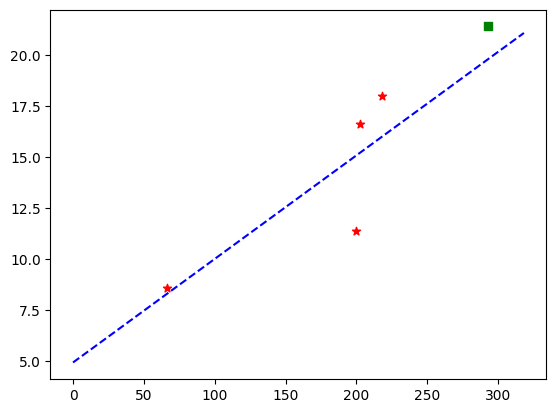

yTest:  21.4 ; yPredict:  47.54887573867295
Residual distance for test data:  -26.14887573867295
Polynomial fit: degree =  2


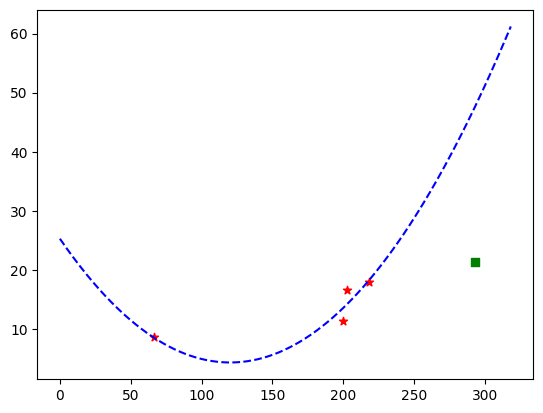

yTest:  21.4 ; yPredict:  -1105.2040589422395
Residual distance for test data:  1126.6040589422396
Polynomial fit: degree =  3


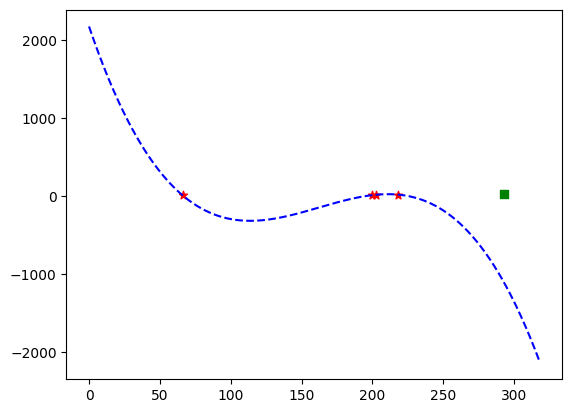

yTest:  21.4 ; yPredict:  -639.8022691547849
Residual distance for test data:  661.2022691547849
Polynomial fit: degree =  4


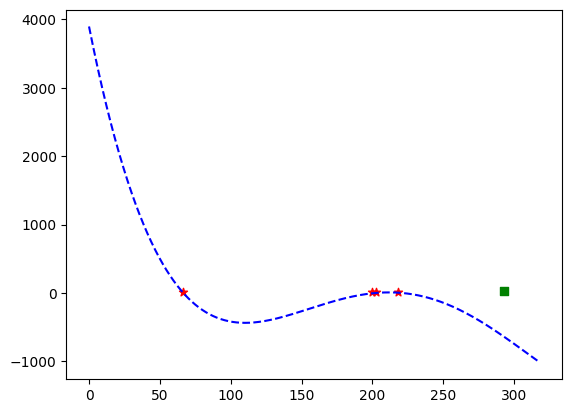

yTest:  21.4 ; yPredict:  -1355.2071235913108
Residual distance for test data:  1376.607123591311
Polynomial fit: degree =  5


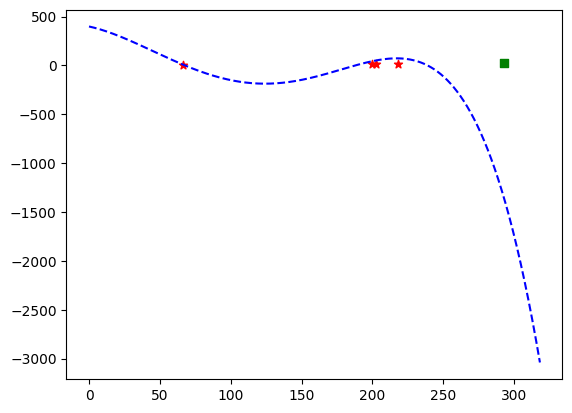

yTest:  21.4 ; yPredict:  -1985.6902149578145
Residual distance for test data:  2007.0902149578146
Polynomial fit: degree =  6


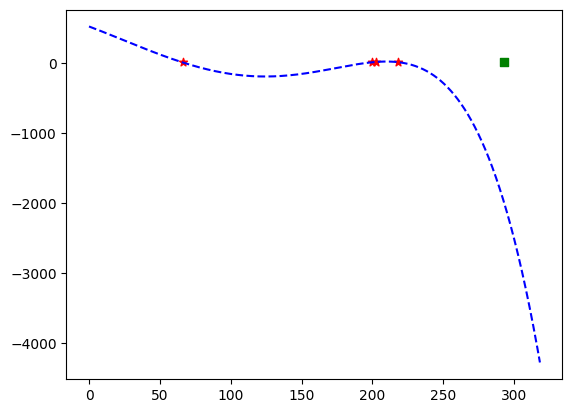

In [5]:
for i in range(1, 7):
    p = polyFit()
    x = p.modelFit(xInput, i) # returns x matrix fit to polynomial
    w = p.minFind(x, yInput) # returns minimum values for features in polynomial
    p.polyPlot(w, xInput, yInput, xTest, yTest)

    